<a href="https://colab.research.google.com/github/nesishaji/DL-ML-Projects/blob/main/Heart_attack/FinalProjects1_HeartAttack_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 With HadHeartAttack as the prediction variable, the task would involve using other features in the dataset to predict whether a patient has experienced a heart attack. This could be approached as a binary classification problem, where the model learns patterns from the other variables to predict the likelihood of HadHeartAttack (0 for no, 1 for yes).


Heart disease is one of the leading causes of mortality worldwide, with heart attacks being a primary manifestation. Early detection and intervention can significantly reduce the risk and improve patient outcomes. In this project, we aim to develop a predictive model that leverages patient demographic, health, and lifestyle information to determine the likelihood of a heart attack occurrence. By analyzing this data, healthcare providers may gain insights into high-risk patients, enabling proactive measures and better allocation of medical resources.

The objective is to predict whether a patient has had a heart attack (binary outcome: HadHeartAttack) based on a range of features, including medical history, lifestyle habits, and demographic details. This model could serve as an assistive tool in clinical decision-making and help in implementing preventive healthcare strategies.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Load the Patients dataset

df=pd.read_csv('/content/Patients Data ( Used for Heart Disease Prediction ) (8).csv')
df.head()

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0


In [ ]:
df.tail()

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
237625,237626,Puerto Rico,Female,Good,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,Not at all (right now),0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,Good,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,Not at all (right now),0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,Fair,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,Not at all (right now),1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,Very good,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,Never used e-cigarettes in my entire life,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1
237629,237630,Puerto Rico,Female,Good,Age 30 to 34,1.60,83.010002,32.419998,0,0,...,Never used e-cigarettes in my entire life,1,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,0


## **2 .Understand the Data Types and Summary**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   PatientID                  237630 non-null  int64  
 1   State                      237630 non-null  object 
 2   Sex                        237630 non-null  object 
 3   GeneralHealth              237630 non-null  object 
 4   AgeCategory                237630 non-null  object 
 5   HeightInMeters             237630 non-null  float64
 6   WeightInKilograms          237630 non-null  float64
 7   BMI                        237630 non-null  float64
 8   HadHeartAttack             237630 non-null  int64  
 9   HadAngina                  237630 non-null  int64  
 10  HadStroke                  237630 non-null  int64  
 11  HadAsthma                  237630 non-null  int64  
 12  HadSkinCancer              237630 non-null  int64  
 13  HadCOPD                    23

In [ ]:
df.shape

(237630, 35)

## **3. Data cleaning**

**Checking null values**

In [ ]:
df.isnull().sum()

,0
PatientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


In [ ]:
df.dropna()
df.dropna(subset=["ChestScan","RaceEthnicityCategory","AlcoholDrinkers","HIVTesting","FluVaxLast12","PneumoVaxEver","TetanusLast10Tdap","HighRiskLastYear","CovidPos"],inplace=True)

In [ ]:
df

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,Alabama,Female,Fair,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,Never used e-cigarettes in my entire life,1,"White only, Non-Hispanic",0,0,0,1,"No, did not receive any tetanus shot in the pa...",0,1
1,2,Alabama,Female,Very good,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received Tdap",0,0
2,3,Alabama,Male,Excellent,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",1,0,0,0,"Yes, received tetanus shot but not sure what type",0,0
3,4,Alabama,Male,Very good,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,Never used e-cigarettes in my entire life,0,"White only, Non-Hispanic",0,0,1,1,"Yes, received tetanus shot but not sure what type",0,0
4,5,Alabama,Female,Good,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,Never used e-cigarettes in my entire life,1,"Black only, Non-Hispanic",0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,Puerto Rico,Female,Good,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,Not at all (right now),0,Hispanic,0,0,1,0,"No, did not receive any tetanus shot in the pa...",0,0
237626,237627,Puerto Rico,Female,Good,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,Not at all (right now),0,Hispanic,0,1,0,0,"Yes, received Tdap",0,0
237627,237628,Puerto Rico,Male,Fair,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,Not at all (right now),1,Hispanic,0,1,1,1,"Yes, received Tdap",1,0
237628,237629,Puerto Rico,Female,Very good,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,Never used e-cigarettes in my entire life,0,Hispanic,0,1,0,0,"No, did not receive any tetanus shot in the pa...",0,1


In [ ]:
df.isnull().sum()

,0
PatientID,0
State,0
Sex,0
GeneralHealth,0
AgeCategory,0
HeightInMeters,0
WeightInKilograms,0
BMI,0
HadHeartAttack,0
HadAngina,0


we can use **unique()** to find **distinct** values in a column and **value_counts()** to see the **frequency of each unique value**.

In [ ]:
print(df['State'].unique())

['Alabama' 'Alaska' 'Arizona' 'California' 'Arkansas' 'Connecticut'
 'Colorado' 'Delaware' 'Florida' 'Georgia' 'Hawaii' 'Idaho' 'Indiana'
 'District of Columbia' 'Kansas' 'Iowa' 'Maryland' 'Minnesota' 'Montana'
 'New Jersey' 'Nebraska' 'New York' 'Ohio' 'Oklahoma' 'Texas' 'Vermont'
 'Washington' 'Utah' 'Illinois' 'West Virginia' 'Virginia' 'Massachusetts'
 'Kentucky' 'Louisiana' 'Maine' 'Wisconsin' 'Michigan' 'Mississippi'
 'Missouri' 'Nevada' 'New Hampshire' 'New Mexico' 'South Carolina'
 'North Carolina' 'North Dakota' 'Oregon' 'Pennsylvania' 'Rhode Island'
 'South Dakota' 'Tennessee' 'Wyoming' 'Guam' 'Puerto Rico'
 'Virgin Islands']


In [ ]:
df['State'].value_counts()

,count
State,
Washington,14241
Maryland,8817
Minnesota,8712
Ohio,8700
New York,8625
Texas,7267
Florida,7124
Kansas,6000
Wisconsin,5890


In [ ]:
print(df['GeneralHealth'].unique())

['Fair' 'Very good' 'Excellent' 'Good' 'Poor']


In [ ]:
df['GeneralHealth'].value_counts()

,count
GeneralHealth,
Very good,83520
Good,74950
Excellent,39911
Fair,29965
Poor,9284


In [ ]:
print(df['Sex'].unique())

['Female' 'Male']


In [ ]:
df['Sex'].value_counts()

,count
Sex,
Female,123293
Male,114337


In [ ]:
print(df['AgeCategory'].unique())

['Age 75 to 79' 'Age 65 to 69' 'Age 60 to 64' 'Age 70 to 74'
 'Age 50 to 54' 'Age 80 or older' 'Age 55 to 59' 'Age 25 to 29'
 'Age 40 to 44' 'Age 30 to 34' 'Age 35 to 39' 'Age 18 to 24'
 'Age 45 to 49']


In [ ]:
df['AgeCategory'].value_counts()

,count
AgeCategory,
Age 65 to 69,27547
Age 60 to 64,25685
Age 70 to 74,24946
Age 55 to 59,21422
Age 50 to 54,19154
Age 75 to 79,17679
Age 80 or older,17544
Age 40 to 44,16228
Age 45 to 49,16095


In [ ]:
print(df['HadDiabetes'].unique())

['Yes' 'No' 'No, pre-diabetes or borderline diabetes'
 'Yes, but only during pregnancy (female)']


In [ ]:
df['HadDiabetes'].value_counts()

,count
HadDiabetes,
No,197463
Yes,33055
"No, pre-diabetes or borderline diabetes",5211
"Yes, but only during pregnancy (female)",1901


In [ ]:
print(df['SmokerStatus'].unique())

['Former smoker' 'Never smoked' 'Current smoker - now smokes every day'
 'Current smoker - now smokes some days']


In [ ]:
df['SmokerStatus'].value_counts()

,count
SmokerStatus,
Never smoked,142390
Former smoker,66193
Current smoker - now smokes every day,21148
Current smoker - now smokes some days,7899


In [ ]:
print(df['ECigaretteUsage'].unique())

['Never used e-cigarettes in my entire life' 'Not at all (right now)'
 'Use them some days' 'Use them every day']


In [ ]:
df['ECigaretteUsage'].value_counts()

,count
ECigaretteUsage,
Never used e-cigarettes in my entire life,183446
Not at all (right now),41963
Use them some days,6468
Use them every day,5753


In [ ]:
print(df['RaceEthnicityCategory'].unique())

['White only, Non-Hispanic' 'Black only, Non-Hispanic'
 'Other race only, Non-Hispanic' 'Multiracial, Non-Hispanic' 'Hispanic']


In [ ]:
df['RaceEthnicityCategory'].value_counts()

,count
RaceEthnicityCategory,
"White only, Non-Hispanic",179369
Hispanic,22023
"Black only, Non-Hispanic",19053
"Other race only, Non-Hispanic",11802
"Multiracial, Non-Hispanic",5383


In [ ]:
print(df['TetanusLast10Tdap'].unique())

['No, did not receive any tetanus shot in the past 10 years'
 'Yes, received Tdap' 'Yes, received tetanus shot but not sure what type'
 'Yes, received tetanus shot, but not Tdap']


In [ ]:
df['TetanusLast10Tdap'].value_counts()

,count
TetanusLast10Tdap,
"No, did not receive any tetanus shot in the past 10 years",79370
"Yes, received tetanus shot but not sure what type",71538
"Yes, received Tdap",67418
"Yes, received tetanus shot, but not Tdap",19304


###  cheking  if in this dataset exists duplicates or not

In [ ]:
df.duplicated().sum()

np.int64(0)

### ** Convert all object data to numerical**

In [ ]:
# Converting all the nominal datas to numerical values using labelencoder class
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [ ]:

df["State"]=le.fit_transform(df["State"])
df["SmokerStatus"]=le.fit_transform(df["SmokerStatus"])
df["ECigaretteUsage"]=le.fit_transform(df["ECigaretteUsage"])
df["RaceEthnicityCategory"]=le.fit_transform(df["RaceEthnicityCategory"])


In [ ]:
df["TetanusLast10Tdap"]=le.fit_transform(df["TetanusLast10Tdap"])

In [ ]:
# replacing "GeneralHealth" because its ordinal data so replacing is better accurate
df["GeneralHealth"].replace(['Fair','Very good','Excellent','Good','Poor'],[1,2,3,4,5],inplace=True)
df

/tmp/ipykernel_6782/1546217485.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["GeneralHealth"].replace(['Fair','Very good','Excellent','Good','Poor'],[1,2,3,4,5],inplace=True)
/tmp/ipykernel_6782/1546217485.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["GeneralHealth"].replace(['Fai

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,ECigaretteUsage,ChestScan,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos
0,1,0,Female,1,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,0,1,4,0,0,0,1,0,0,1
1,2,0,Female,2,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,0,0,4,0,0,1,1,1,0,0
2,3,0,Male,3,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,0,0,4,1,0,0,0,2,0,0
3,4,0,Male,2,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,0,0,4,0,0,1,1,2,0,0
4,5,0,Female,4,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,40,Female,4,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,1,0,1,0,0,1,0,0,0,0
237626,237627,40,Female,4,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,1,0,1,0,1,0,0,1,0,0
237627,237628,40,Male,1,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,1,1,1,0,1,1,1,1,1,0
237628,237629,40,Female,2,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,0,0,1,0,1,0,0,0,0,1


In [ ]:
df["TetanusLast10Tdap"]=le.fit_transform(df["TetanusLast10Tdap"])


In [ ]:
dummies=pd.get_dummies(df["Sex"]).astype(int)
dummies

,Female,Male
0,1,0
1,1,0
2,0,1
3,0,1
4,1,0
...,...,...
237625,1,0
237626,1,0
237627,0,1
237628,1,0


In [ ]:
df = pd.concat([df,dummies],axis="columns")
df

,PatientID,State,Sex,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,...,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,Female,Male
0,1,0,Female,1,Age 75 to 79,1.63,84.820000,32.099998,0,1,...,4,0,0,0,1,0,0,1,1,0
1,2,0,Female,2,Age 65 to 69,1.60,71.669998,27.990000,0,0,...,4,0,0,1,1,1,0,0,1,0
2,3,0,Male,3,Age 60 to 64,1.78,71.209999,22.530001,0,0,...,4,1,0,0,0,2,0,0,0,1
3,4,0,Male,2,Age 70 to 74,1.78,95.250000,30.129999,0,0,...,4,0,0,1,1,2,0,0,0,1
4,5,0,Female,4,Age 50 to 54,1.68,78.019997,27.760000,0,0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,40,Female,4,Age 60 to 64,1.57,90.720001,36.580002,0,0,...,1,0,0,1,0,0,0,0,1,0
237626,237627,40,Female,4,Age 55 to 59,1.70,72.570000,25.059999,0,1,...,1,0,1,0,0,1,0,0,1,0
237627,237628,40,Male,1,Age 45 to 49,1.75,70.309998,22.889999,1,1,...,1,0,1,1,1,1,1,0,0,1
237628,237629,40,Female,2,Age 25 to 29,1.57,46.720001,18.840000,0,0,...,1,0,1,0,0,0,0,1,1,0


In [ ]:
# drope the orginal variable
df.drop(["Sex"],axis="columns",inplace=True)
df

,PatientID,State,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,HadStroke,...,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,Female,Male
0,1,0,1,Age 75 to 79,1.63,84.820000,32.099998,0,1,0,...,4,0,0,0,1,0,0,1,1,0
1,2,0,2,Age 65 to 69,1.60,71.669998,27.990000,0,0,0,...,4,0,0,1,1,1,0,0,1,0
2,3,0,3,Age 60 to 64,1.78,71.209999,22.530001,0,0,0,...,4,1,0,0,0,2,0,0,0,1
3,4,0,2,Age 70 to 74,1.78,95.250000,30.129999,0,0,0,...,4,0,0,1,1,2,0,0,0,1
4,5,0,4,Age 50 to 54,1.68,78.019997,27.760000,0,0,0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,40,4,Age 60 to 64,1.57,90.720001,36.580002,0,0,0,...,1,0,0,1,0,0,0,0,1,0
237626,237627,40,4,Age 55 to 59,1.70,72.570000,25.059999,0,1,0,...,1,0,1,0,0,1,0,0,1,0
237627,237628,40,1,Age 45 to 49,1.75,70.309998,22.889999,1,1,0,...,1,0,1,1,1,1,1,0,0,1
237628,237629,40,2,Age 25 to 29,1.57,46.720001,18.840000,0,0,0,...,1,0,1,0,0,0,0,1,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 36 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   PatientID                  237630 non-null  int64  
 1   State                      237630 non-null  int64  
 2   GeneralHealth              237630 non-null  int64  
 3   AgeCategory                237630 non-null  object 
 4   HeightInMeters             237630 non-null  float64
 5   WeightInKilograms          237630 non-null  float64
 6   BMI                        237630 non-null  float64
 7   HadHeartAttack             237630 non-null  int64  
 8   HadAngina                  237630 non-null  int64  
 9   HadStroke                  237630 non-null  int64  
 10  HadAsthma                  237630 non-null  int64  
 11  HadSkinCancer              237630 non-null  int64  
 12  HadCOPD                    237630 non-null  int64  
 13  HadDepressiveDisorder      23

In [ ]:
df["HadDiabetes"]=le.fit_transform(df["HadDiabetes"])

In [ ]:
# replacing "AgeCategory" because its ordinal data so replacing is better accurate
df["AgeCategory"].replace(['Age 75 to 79','Age 65 to 69','Age 60 to 64','Age 70 to 74',
 'Age 50 to 54','Age 80 or older','Age 55 to 59','Age 25 to 29',
 'Age 40 to 44','Age 30 to 34','Age 35 to 39','Age 18 to 24',
 'Age 45 to 49'],[1,2,3,4,5,6,7,8,9,10,11,12,13],inplace=True)
df

/tmp/ipykernel_6782/3104638559.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["AgeCategory"].replace(['Age 75 to 79','Age 65 to 69','Age 60 to 64','Age 70 to 74',
/tmp/ipykernel_6782/3104638559.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["AgeCategory"].replace(['Age 75 to 79','Age

,PatientID,State,GeneralHealth,AgeCategory,HeightInMeters,WeightInKilograms,BMI,HadHeartAttack,HadAngina,HadStroke,...,RaceEthnicityCategory,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,Female,Male
0,1,0,1,1,1.63,84.820000,32.099998,0,1,0,...,4,0,0,0,1,0,0,1,1,0
1,2,0,2,2,1.60,71.669998,27.990000,0,0,0,...,4,0,0,1,1,1,0,0,1,0
2,3,0,3,3,1.78,71.209999,22.530001,0,0,0,...,4,1,0,0,0,2,0,0,0,1
3,4,0,2,4,1.78,95.250000,30.129999,0,0,0,...,4,0,0,1,1,2,0,0,0,1
4,5,0,4,5,1.68,78.019997,27.760000,0,0,0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237625,237626,40,4,3,1.57,90.720001,36.580002,0,0,0,...,1,0,0,1,0,0,0,0,1,0
237626,237627,40,4,7,1.70,72.570000,25.059999,0,1,0,...,1,0,1,0,0,1,0,0,1,0
237627,237628,40,1,13,1.75,70.309998,22.889999,1,1,0,...,1,0,1,1,1,1,1,0,0,1
237628,237629,40,2,8,1.57,46.720001,18.840000,0,0,0,...,1,0,1,0,0,0,0,1,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237630 entries, 0 to 237629
Data columns (total 36 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   PatientID                  237630 non-null  int64  
 1   State                      237630 non-null  int64  
 2   GeneralHealth              237630 non-null  int64  
 3   AgeCategory                237630 non-null  int64  
 4   HeightInMeters             237630 non-null  float64
 5   WeightInKilograms          237630 non-null  float64
 6   BMI                        237630 non-null  float64
 7   HadHeartAttack             237630 non-null  int64  
 8   HadAngina                  237630 non-null  int64  
 9   HadStroke                  237630 non-null  int64  
 10  HadAsthma                  237630 non-null  int64  
 11  HadSkinCancer              237630 non-null  int64  
 12  HadCOPD                    237630 non-null  int64  
 13  HadDepressiveDisorder      23

## **Visualization**

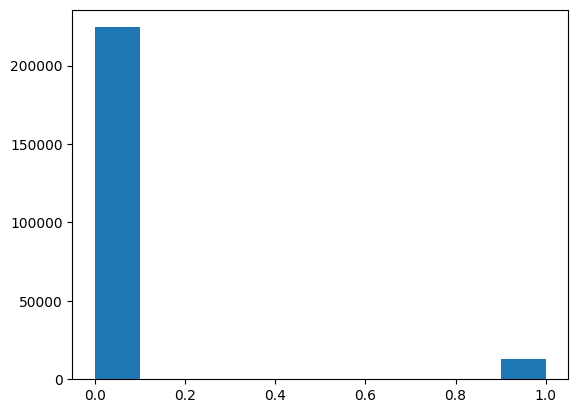

In [ ]:
plt.hist(df["HadHeartAttack"])
plt.show()

<Axes: >

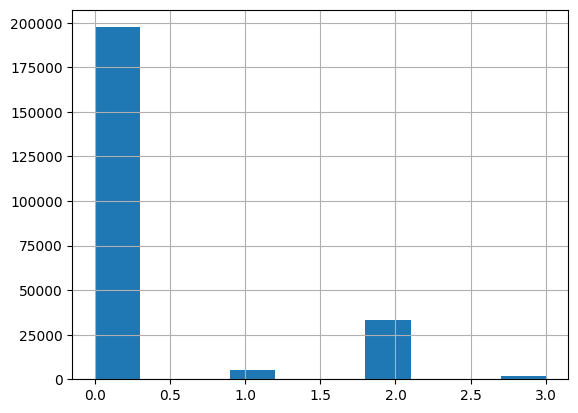

In [ ]:
# check HadDiabetes distribution

df["HadDiabetes"].hist()

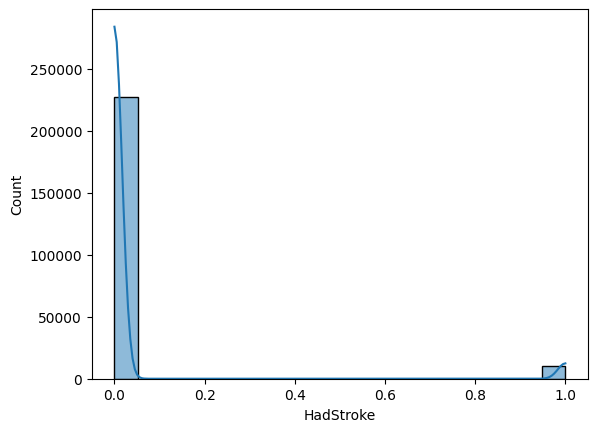

In [ ]:
sns.histplot(df['HadStroke'], kde=True)
plt.show()

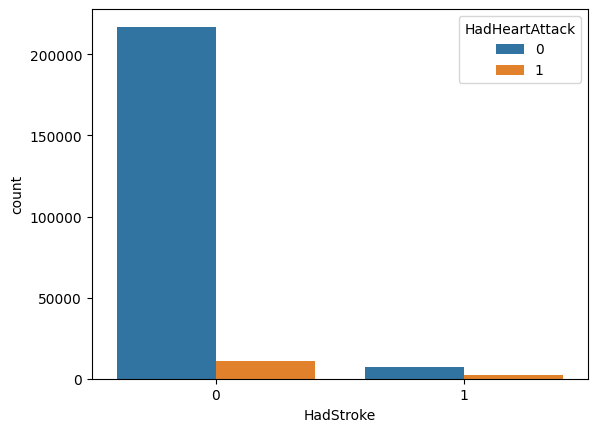

In [ ]:
sns.countplot(data=df, x='HadStroke', hue='HadHeartAttack')
plt.show()

In [ ]:
# After finding its imbalance, oversampling method is used

from imblearn.over_sampling import SMOTE

# Split into features and target
x = df.drop('HadHeartAttack', axis=1)
y = df['HadHeartAttack']

smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x, y)

df = pd.concat([x_resampled, y_resampled], axis=1)

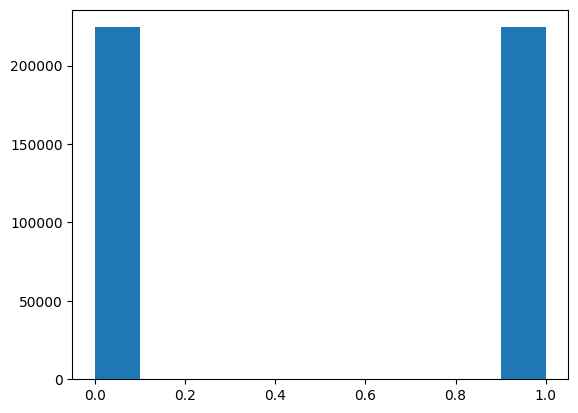

In [ ]:
plt.hist(df["HadHeartAttack"])
plt.show()

### After converting check correlation

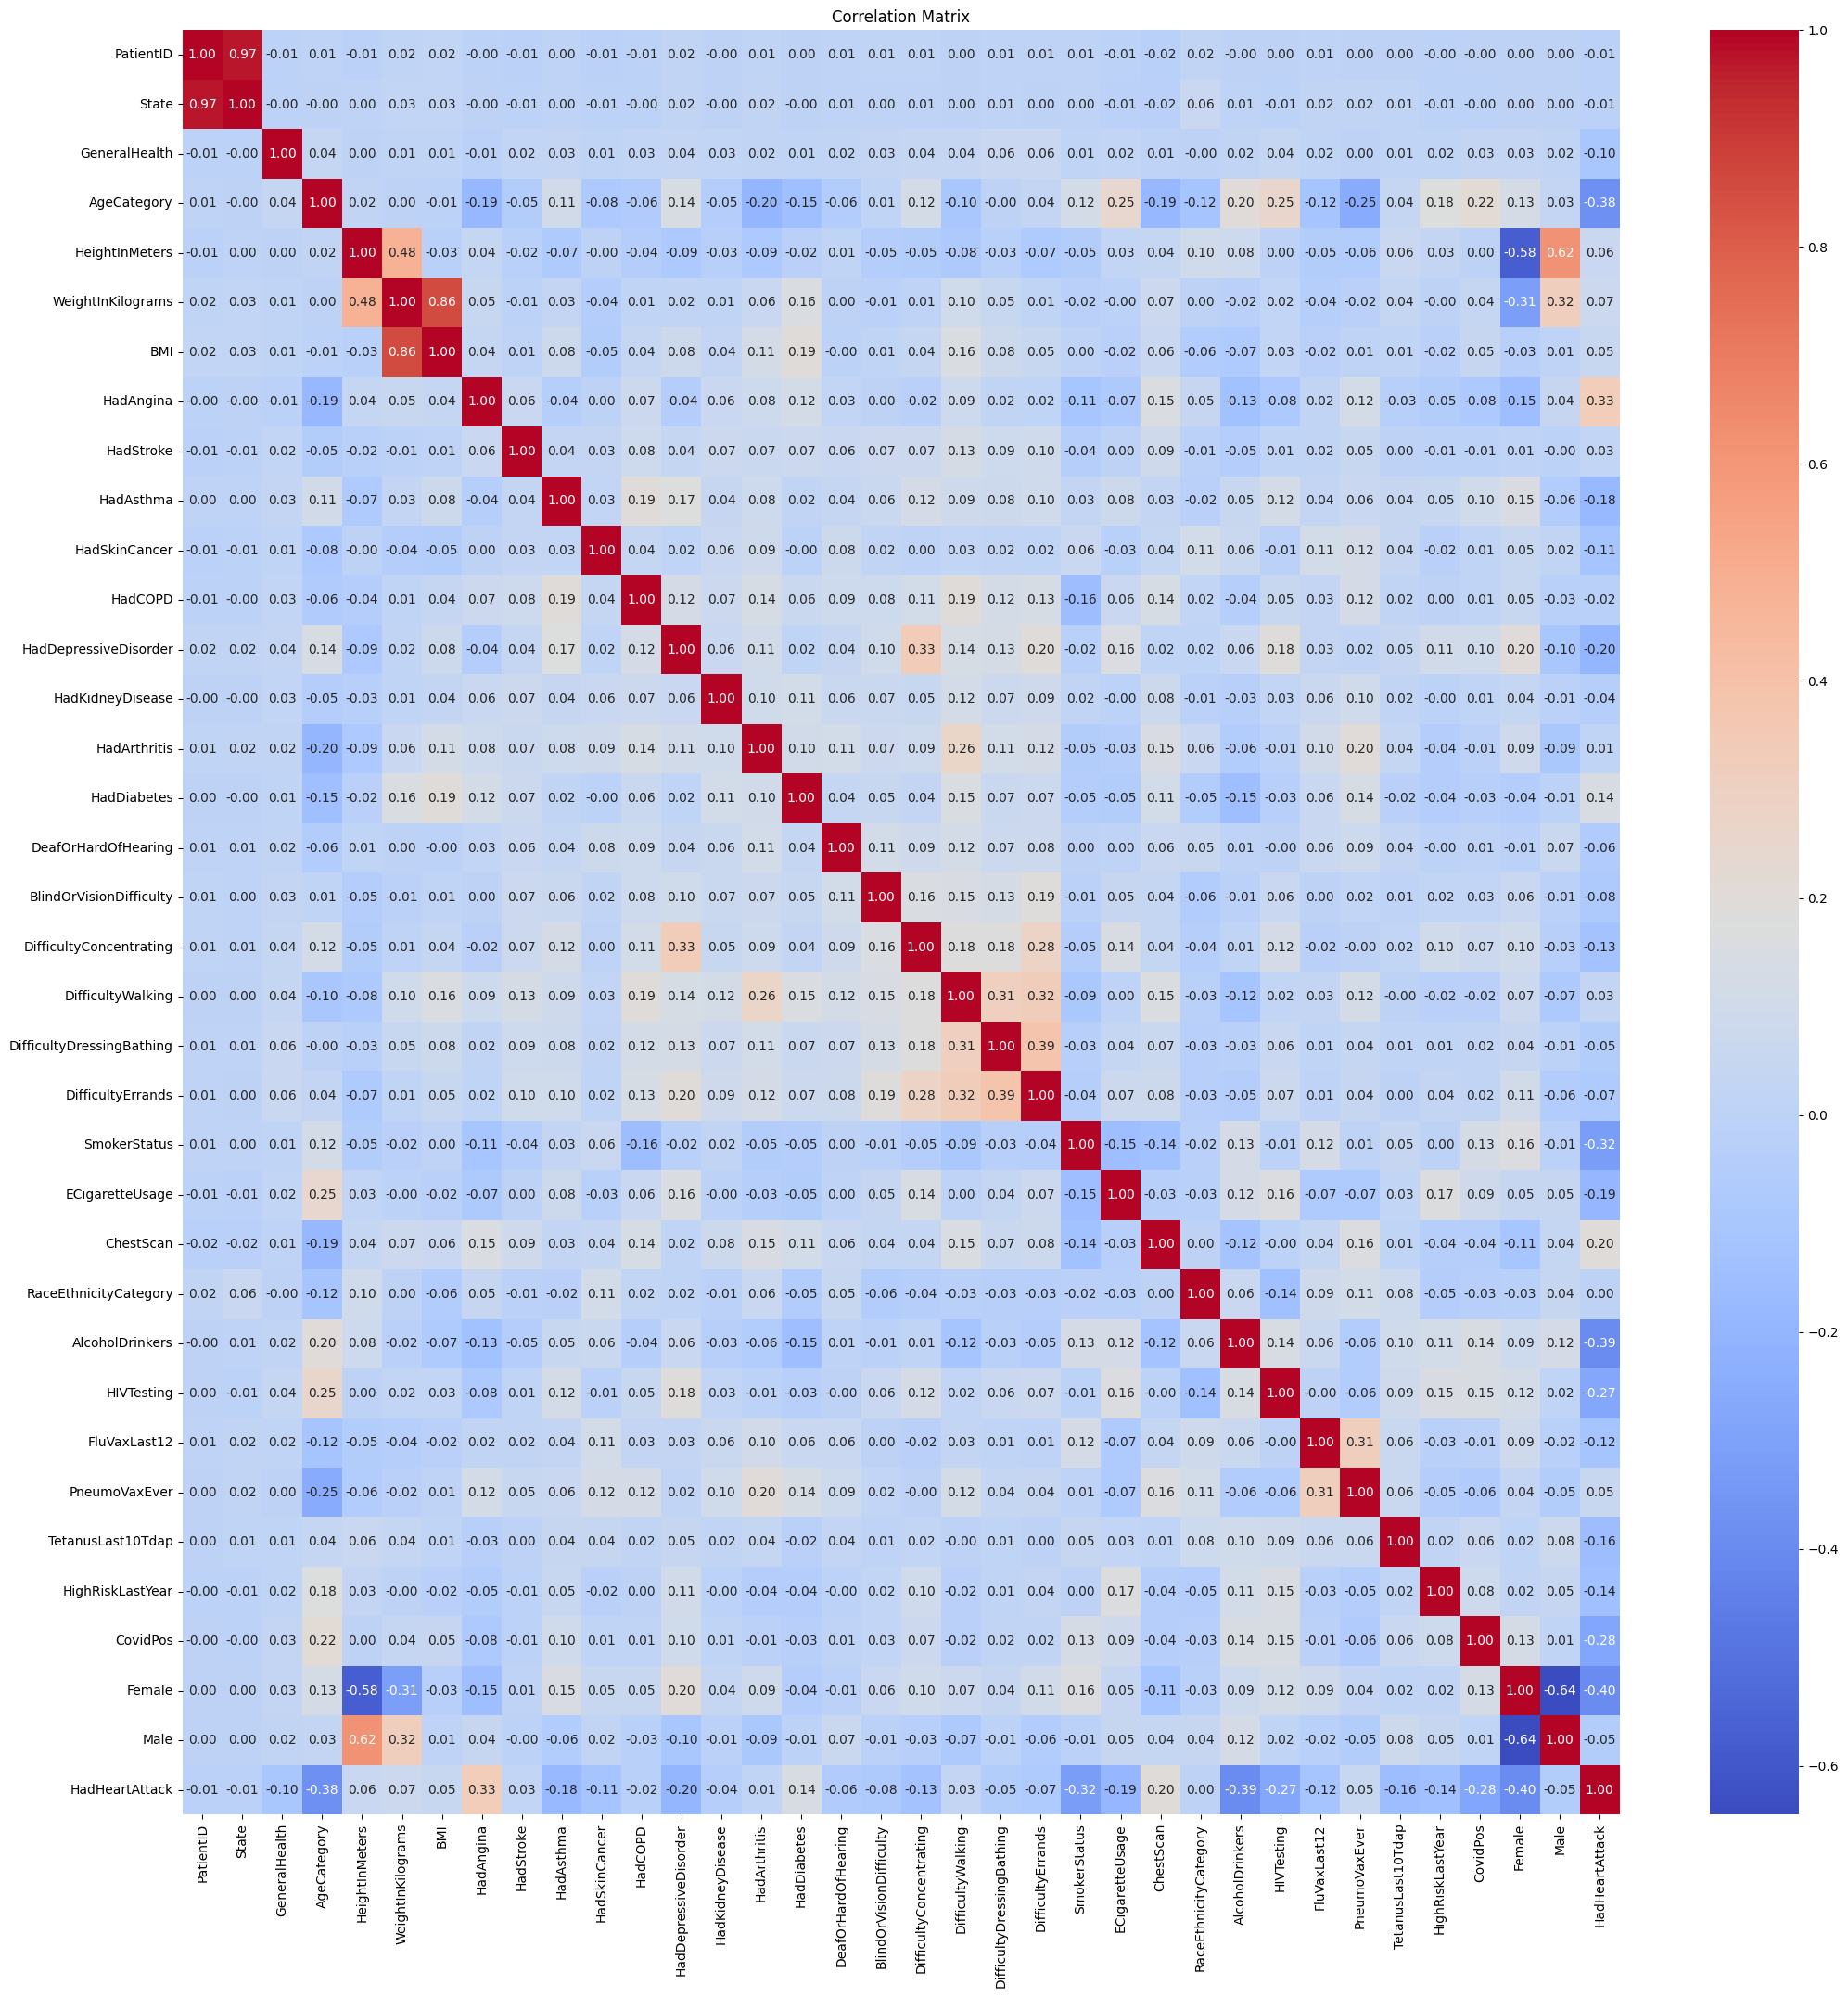

In [ ]:
# Correlation matrix
plt.figure(figsize=(25, 25))
corr_matrix = df.corr()

# Heatmap of correlation matrix
sns.heatmap(corr_matrix,annot=True, fmt='0.02f', cmap='coolwarm') # 0.01f should be given for float values, d for integers
plt.title('Correlation Matrix')
plt.show()

### check : -Collinearity  ,multicollinearity

- Male and female have multicollinearity so Take only one column

In [ ]:
df.drop(["Male"],axis=1,inplace=True)

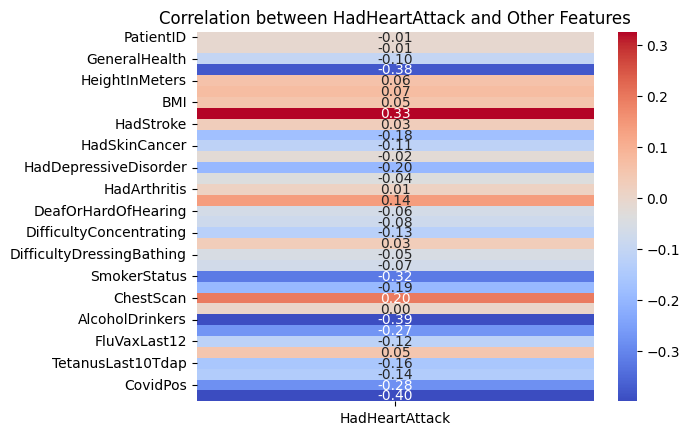

In [ ]:
# Calculate the correlation between 'HadHeartAttack' and all other columns
HadHeartAttack_corr = df.corr()['HadHeartAttack']

# Remove the correlation of 'HadHeartAttack'with itself (which is always 1)
HadHeartAttack_corr = HadHeartAttack_corr.drop('HadHeartAttack')

# Create a heatmap to visualize the correlations
sns.heatmap(HadHeartAttack_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})  # to_frame() converts Series to DataFrame for heatmap
plt.title('Correlation between HadHeartAttack and Other Features')
plt.show()

###  **Now remove less correlated**

In [ ]:
df.drop(["PatientID","State","GeneralHealth","HeightInMeters","WeightInKilograms","BMI"],axis=1,inplace=True)



In [ ]:
df.drop(["HadAsthma","HadSkinCancer","HadDepressiveDisorder","DifficultyConcentrating","ECigaretteUsage","RaceEthnicityCategory"],axis=1,inplace=True)

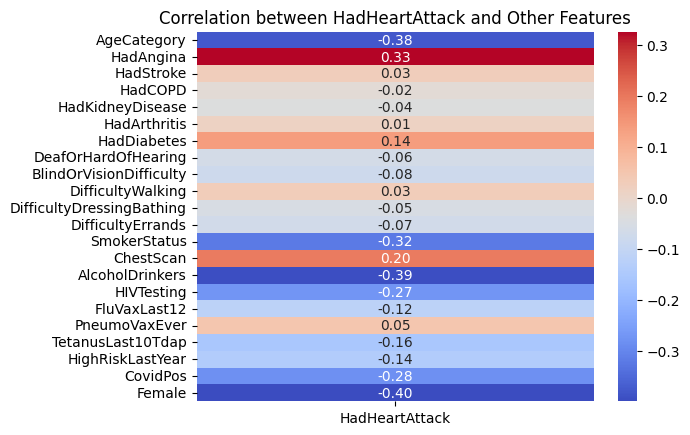

In [ ]:
# Calculate the correlation between 'HadHeartAttack' and all other columns
HadHeartAttack_corr = df.corr()['HadHeartAttack']

# Remove the correlation of 'HadHeartAttack'with itself (which is always 1)
HadHeartAttack_corr = HadHeartAttack_corr.drop('HadHeartAttack')

# Create a heatmap to visualize the correlations
sns.heatmap(HadHeartAttack_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})  # to_frame() converts Series to DataFrame for heatmap
plt.title('Correlation between HadHeartAttack and Other Features')
plt.show()

In [ ]:
df.drop(["TetanusLast10Tdap","HighRiskLastYear","CovidPos","HIVTesting","FluVaxLast12"],axis=1,inplace=True)



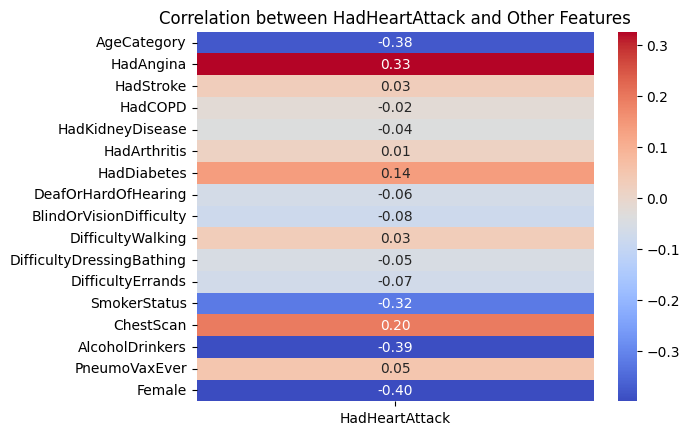

In [ ]:
# Calculate the correlation between 'HadHeartAttack' and all other columns
HadHeartAttack_corr = df.corr()['HadHeartAttack']

# Remove the correlation of 'HadHeartAttack'with itself (which is always 1)
HadHeartAttack_corr = HadHeartAttack_corr.drop('HadHeartAttack')

# Create a heatmap to visualize the correlations
sns.heatmap(HadHeartAttack_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})  # to_frame() converts Series to DataFrame for heatmap
plt.title('Correlation between HadHeartAttack and Other Features')
plt.show()

In [ ]:
df.shape

(448858, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448858 entries, 0 to 448857
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype
---  ------                     --------------   -----
 0   AgeCategory                448858 non-null  int64
 1   HadAngina                  448858 non-null  int64
 2   HadStroke                  448858 non-null  int64
 3   HadCOPD                    448858 non-null  int64
 4   HadKidneyDisease           448858 non-null  int64
 5   HadArthritis               448858 non-null  int64
 6   HadDiabetes                448858 non-null  int64
 7   DeafOrHardOfHearing        448858 non-null  int64
 8   BlindOrVisionDifficulty    448858 non-null  int64
 9   DifficultyWalking          448858 non-null  int64
 10  DifficultyDressingBathing  448858 non-null  int64
 11  DifficultyErrands          448858 non-null  int64
 12  SmokerStatus               448858 non-null  int64
 13  ChestScan                  448858 non-null  int64
 14  Alco

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler



# Select the features that you want to scale
features = ['AgeCategory', 'HadAngina', 'HadStroke',"HadCOPD","HadKidneyDisease","HadArthritis",'HadDiabetes', 'DeafOrHardOfHearing',
            'BlindOrVisionDifficulty',"DifficultyWalking","DifficultyDressingBathing","DifficultyErrands",'SmokerStatus', 'ChestScan',
            'AlcoholDrinkers',"PneumoVaxEver","Female"]

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Fit the scaler to your data and transform it
scaled_data = scaler.fit_transform(df[features])

# Create a DataFrame from scaled_data with the correct column names
scaled_df = pd.DataFrame(scaled_data, columns=features)

# After **EDA** we can predict

## Use LogisticRegression model if our dataset is classification (means discrete)  & if our dataset is regression (means continuous) use LinearRegression

# 1. Logistic Regression

In [ ]:
# use logisticRegression because our dataset is classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd # Import pandas



X = scaled_df[['AgeCategory', 'HadAngina', 'HadStroke',"HadCOPD","HadKidneyDisease","HadArthritis",'HadDiabetes', 'DeafOrHardOfHearing',
            'BlindOrVisionDifficulty',"DifficultyWalking","DifficultyDressingBathing","DifficultyErrands",'SmokerStatus', 'ChestScan',
            'AlcoholDrinkers',"PneumoVaxEver","Female"]]  # Features
y = df['HadHeartAttack']  # Target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42) # You can adjust the test_size and random_state



# Train a baseline logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict and evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.82


## 2. KFOLD

In [ ]:
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [ ]:
# Split features and target
X = df.drop('HadHeartAttack', axis=1)
y = df['HadHeartAttack']

# KFold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression()

# Track best fold data
best_accuracy = 0
best_fold = -1


# Save best fold's data
best_X_train = None
best_y_train = None
best_X_test = None
best_y_test = None
best_y_pred = None

# Loop over each fold
for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Fold {fold} Accuracy: {acc}")

    # Update best fold
    if acc > best_accuracy:
        best_accuracy = acc
        best_fold = fold
        best_X_train = X_train
        best_y_train = y_train
        best_X_test = X_test
        best_y_test = y_test
        best_y_pred = y_pred

# Output best fold details
print(f"\n Best Fold: {best_fold} with Accuracy: {best_accuracy}")

Fold 1 Accuracy: 0.8188187853673752
Fold 2 Accuracy: 0.8196876531657978
Fold 3 Accuracy: 0.8210800695094239
Fold 4 Accuracy: 0.8199752704102661
Fold 5 Accuracy: 0.8216684675451983

 Best Fold: 5 with Accuracy: 0.8216684675451983


In [ ]:
model = LogisticRegression()
model.fit(best_X_train,best_y_train)
model.score(best_X_test,best_y_test)

0.8216684675451983

## 3. Decision Tree Algorithm

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd # Import pandas


X = df[['AgeCategory', 'HadAngina', 'HadStroke',"HadCOPD","HadKidneyDisease","HadArthritis",'HadDiabetes', 'DeafOrHardOfHearing',
            'BlindOrVisionDifficulty',"DifficultyWalking","DifficultyDressingBathing","DifficultyErrands",'SmokerStatus', 'ChestScan',
            'AlcoholDrinkers',"PneumoVaxEver","Female"]]  # Features
y = df['HadHeartAttack']  # Target variable


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42) # You can adjust the test_size and random_state



# Train DecisionTree Classifier
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Predict and evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.85


## 4. Support Vector Machine(SVM)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
from sklearn.svm import SVC

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

In [ ]:
X=df[['AgeCategory', 'HadAngina', 'HadStroke',"HadCOPD","HadKidneyDisease","HadArthritis",'HadDiabetes', 'DeafOrHardOfHearing',
            'BlindOrVisionDifficulty',"DifficultyWalking","DifficultyDressingBathing","DifficultyErrands",'SmokerStatus', 'ChestScan',
            'AlcoholDrinkers',"PneumoVaxEver","Female"]]
y = df['HadHeartAttack']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',LinearSVC())
])

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f'Linear SVC Pipeline accuracy: {accuracy:.2f}')

Linear SVC Pipeline accuracy: 0.82


## 5. Random Forest Classifier

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier


Using Random Forest Classifier

In [ ]:
X=df[['AgeCategory', 'HadAngina', 'HadStroke',"HadCOPD","HadKidneyDisease","HadArthritis",'HadDiabetes', 'DeafOrHardOfHearing',
            'BlindOrVisionDifficulty',"DifficultyWalking","DifficultyDressingBathing","DifficultyErrands",'SmokerStatus', 'ChestScan',
            'AlcoholDrinkers',"PneumoVaxEver","Female"]]
y = df['HadHeartAttack']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

# Predict and evaluate the model

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')


Baseline model accuracy: 0.86


##**6. XG Boost**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# Features and target
X = df[['AgeCategory', 'HadAngina', 'HadStroke',"HadCOPD","HadKidneyDisease","HadArthritis",
        'HadDiabetes', 'DeafOrHardOfHearing','BlindOrVisionDifficulty',"DifficultyWalking",
        "DifficultyDressingBathing","DifficultyErrands",'SmokerStatus', 'ChestScan',
        'AlcoholDrinkers',"PneumoVaxEver","Female"]]

y = df['HadHeartAttack']

In [ ]:
model = XGBClassifier()
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

Predictions

In [ ]:
y_pred = model.predict(X_test)

Evaluation

In [ ]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.86


## 7. Ada Boost Classifier

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

Define features and target

In [ ]:
X = df[['AgeCategory', 'HadAngina', 'HadStroke',"HadCOPD","HadKidneyDisease","HadArthritis",
        'HadDiabetes', 'DeafOrHardOfHearing','BlindOrVisionDifficulty',"DifficultyWalking",
        "DifficultyDressingBathing","DifficultyErrands",'SmokerStatus', 'ChestScan',
        'AlcoholDrinkers',"PneumoVaxEver","Female"]]

y = df['HadHeartAttack']

Train AdaBoost model

In [ ]:
model = AdaBoostClassifier()

model.fit(X_train, y_train)

AdaBoostClassifier()

Predictions

In [ ]:
y_pred = model.predict(X_test)

Evaluation

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline model accuracy: {accuracy:.2f}')

Baseline model accuracy: 0.84


##  8. Deep Learning

##Artificial Neural Networks (ANN)

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Features and target
X = df[['AgeCategory', 'HadAngina', 'HadStroke',"HadCOPD","HadKidneyDisease","HadArthritis",
        'HadDiabetes', 'DeafOrHardOfHearing','BlindOrVisionDifficulty',"DifficultyWalking",
        "DifficultyDressingBathing","DifficultyErrands",'SmokerStatus', 'ChestScan',
        'AlcoholDrinkers',"PneumoVaxEver","Female"]]

y = df['HadHeartAttack']

In [ ]:
# Defining the ANN model
model = Sequential()
model.add(Dense(64, input_shape=(17,), activation='relu'))  # Hidden Layer 1
model.add(Dense(32, activation='relu'))               # Hidden Layer 2
model.add(Dense(1, activation='sigmoid'))             # Output Layer

# Compiling the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compiling the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
# Training the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 27s 2ms/step - accuracy: 0.8371 - loss: 0.3633
Epoch 2/10
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8441 - loss: 0.3490
Epoch 3/10
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.8451 - loss: 0.3464
Epoch 4/10
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.8464 - loss: 0.3443
Epoch 5/10
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8477 - loss: 0.3427
Epoch 6/10
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.8478 - loss: 0.3416
Epoch 7/10
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.8490 - loss: 0.3405
Epoch 8/10
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8490 - loss: 0.3398
Epoch 9/10
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8499 - loss: 0.3390
Epoch 10/10
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.8502 - loss: 0.3383


In [ ]:

# Evaluating the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

3507/3507 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8494 - loss: 0.3398
Model Accuracy: 84.94%


In [ ]:
# Training the model
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.8503 - loss: 0.3378
Epoch 2/20
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8505 - loss: 0.3372
Epoch 3/20
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8508 - loss: 0.3368
Epoch 4/20
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.8510 - loss: 0.3363
Epoch 5/20
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.8512 - loss: 0.3359
Epoch 6/20
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.8516 - loss: 0.3354
Epoch 7/20
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8519 - loss: 0.3349
Epoch 8/20
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.8517 - loss: 0.3346
Epoch 9/20
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8519 - loss: 0.3344
Epoch 10/20
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.8523 - loss: 0.3339
Epoch 11/20
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - accuracy: 0.8524 - loss: 0.33

In [ ]:
# Evaluating the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

3507/3507 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8514 - loss: 0.3371
Model Accuracy: 85.14%


In [ ]:
# Training the model
model.fit(X_train, y_train, epochs=40, batch_size=32)

Epoch 1/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.8540 - loss: 0.3307
Epoch 2/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8545 - loss: 0.3304
Epoch 3/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.8546 - loss: 0.3304
Epoch 4/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8548 - loss: 0.3302
Epoch 5/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.8548 - loss: 0.3300
Epoch 6/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8551 - loss: 0.3297
Epoch 7/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8552 - loss: 0.3297
Epoch 8/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8552 - loss: 0.3293
Epoch 9/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.8557 - loss: 0.3291
Epoch 10/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.8554 - loss: 0.3291
Epoch 11/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.8552 - loss: 0.32

In [ ]:
# Evaluating the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

3507/3507 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8525 - loss: 0.3360
Model Accuracy: 85.25%


In [ ]:
# Training the model
model.fit(X_train, y_train, epochs=70, batch_size=32)

Epoch 1/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8571 - loss: 0.3259
Epoch 2/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.8573 - loss: 0.3257
Epoch 3/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8571 - loss: 0.3258
Epoch 4/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8574 - loss: 0.3256
Epoch 5/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8570 - loss: 0.3256
Epoch 6/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8571 - loss: 0.3254
Epoch 7/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.8572 - loss: 0.3253
Epoch 8/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.8572 - loss: 0.3253
Epoch 9/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.8576 - loss: 0.3252
Epoch 10/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.8573 - loss: 0.3252
Epoch 11/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 43s 3ms/step - accuracy: 0.8574 - loss: 0.32

In [ ]:
# Evaluating the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

3507/3507 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.8523 - loss: 0.3369
Model Accuracy: 85.23%


In [ ]:
# Defining the ANN model
model = Sequential()
model.add(Dense(128, input_shape=(17,), activation='relu')) # Hidden Layer 1
model.add(Dense(64, activation='relu'))  # Hidden Layer 2
model.add(Dense(32, activation='relu'))               # Hidden Layer 3
model.add(Dense(1, activation='sigmoid'))             # Output Layer

# Compiling the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Training the model
model.fit(X_train, y_train, epochs=40, batch_size=32)

Epoch 1/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.8380 - loss: 0.3610
Epoch 2/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.8442 - loss: 0.3490
Epoch 3/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.8451 - loss: 0.3467
Epoch 4/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.8470 - loss: 0.3442
Epoch 5/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.8482 - loss: 0.3421
Epoch 6/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 25s 2ms/step - accuracy: 0.8491 - loss: 0.3409
Epoch 7/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.8495 - loss: 0.3397
Epoch 8/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step - accuracy: 0.8502 - loss: 0.3383
Epoch 9/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - accuracy: 0.8510 - loss: 0.3369
Epoch 10/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 42s 3ms/step - accuracy: 0.8520 - loss: 0.3356
Epoch 11/40
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8531 - loss: 0.33

In [ ]:
# Evaluating the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

3507/3507 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.8535 - loss: 0.3392
Model Accuracy: 85.35%


In [ ]:
# Training the model
model.fit(X_train, y_train, epochs=70, batch_size=32)

Epoch 1/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.8611 - loss: 0.3179
Epoch 2/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.8615 - loss: 0.3176
Epoch 3/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8613 - loss: 0.3176
Epoch 4/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.8617 - loss: 0.3170
Epoch 5/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8616 - loss: 0.3168
Epoch 6/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step - accuracy: 0.8618 - loss: 0.3166
Epoch 7/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 35s 3ms/step - accuracy: 0.8617 - loss: 0.3162
Epoch 8/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - accuracy: 0.8620 - loss: 0.3162
Epoch 9/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8624 - loss: 0.3156
Epoch 10/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8621 - loss: 0.3155
Epoch 11/70
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.8630 - loss: 0.31

In [ ]:
# Evaluating the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

3507/3507 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8543 - loss: 0.3552
Model Accuracy: 85.43%


In [ ]:
# Training the model
model.fit(X_train, y_train, epochs=100, batch_size=32)

Epoch 1/100
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.8662 - loss: 0.3071
Epoch 2/100
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.8659 - loss: 0.3077
Epoch 3/100
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8662 - loss: 0.3074
Epoch 4/100
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.8658 - loss: 0.3073
Epoch 5/100
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.8661 - loss: 0.3073
Epoch 6/100
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.8660 - loss: 0.3071
Epoch 7/100
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.8659 - loss: 0.3070
Epoch 8/100
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 28s 3ms/step - accuracy: 0.8664 - loss: 0.3068
Epoch 9/100
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 26s 2ms/step - accuracy: 0.8664 - loss: 0.3068
Epoch 10/100
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.8662 - loss: 0.3066
Epoch 11/100
10521/10521 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.8667 -

In [ ]:
# Evaluating the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

3507/3507 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.8542 - loss: 0.3775
Model Accuracy: 85.42%


## Conclusion

Conclusion

This project focused on predicting the likelihood of a heart attack using various health and lifestyle factors. Multiple machine learning models were applied and evaluated using cross-validation. Among them, XGBoost achieved the highest accuracy of 86%, indicating its effectiveness in capturing complex relationships within the data. The results show that ensemble learning methods are well-suited for heart attack prediction and can support early risk assessment in healthcare.